# Student productivity — exploratory analysis

Synthetic cohort (~20&nbsp;k rows). Inspect columns, apply the same light cleaning as `app.py`, then sample plots and a correlation matrix.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

We load the CSV and look at the first rows to see what columns we have.

In [2]:
df = pd.read_csv("student_productivity.csv")
df.head()

,student_id,age,gender,study_hours_per_day,sleep_hours,phone_usage_hours,social_media_hours,youtube_hours,gaming_hours,breaks_per_day,coffee_intake_mg,exercise_minutes,assignments_completed,attendance_percentage,stress_level,focus_score,productivity_score,final_grade
0,1,25,Male,4.31,5.64,7.60,3.34,2.41,0.35,9,448 mg,25.0,8,72.49%,9,13.55,40.08,86.92
1,2,26,Female,7.62,4.42,5.24,2.00,2.36,1.22,6,440 mg,33.0,11,88.00%,8,18.53,44.04,64.36
2,3,28,Male,1.38,6.78,9.82,3.87,2.82,2.70,10,402 mg,49.0,0,52.86%,8,0.00,23.48,77.78
3,4,21,Female,5.37,6.66,11.05,5.29,3.03,3.36,9,478 mg,39.0,10,75.52%,8,16.88,27.07,74.69
4,5,17,Male,6.00,7.54,1.37,1.22,0.41,0.00,9,214 mg,57.0,10,77.56%,5,46.65,81.66,73.66


`df.info()` shows column types and how many values are missing. We see that a few columns are stored as text but should be numbers (coffee intake, attendance percentage). We will fix these in the cleaning step.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             20000 non-null  int64  
 1   age                    20000 non-null  int64  
 2   gender                 20000 non-null  object 
 3   study_hours_per_day    20000 non-null  float64
 4   sleep_hours            20000 non-null  float64
 5   phone_usage_hours      19791 non-null  float64
 6   social_media_hours     20000 non-null  float64
 7   youtube_hours          20000 non-null  float64
 8   gaming_hours           20000 non-null  float64
 9   breaks_per_day         20000 non-null  int64  
 10  coffee_intake_mg       19450 non-null  object 
 11  exercise_minutes       19700 non-null  float64
 12  assignments_completed  20000 non-null  int64  
 13  attendance_percentage  20000 non-null  object 
 14  stress_level           20000 non-null  int64  
 15  fo

Quick summary statistics. We look at min, max and mean to spot weird ranges before we start plotting.

In [4]:
df.describe()

,student_id,age,study_hours_per_day,sleep_hours,phone_usage_hours,social_media_hours,youtube_hours,gaming_hours,breaks_per_day,exercise_minutes,assignments_completed,stress_level,focus_score,productivity_score,final_grade
count,20000.000000,20000.000000,20000.000000,20000.000000,19791.000000,20000.000000,20000.000000,20000.000000,20000.000000,19700.000000,20000.00000,20000.000000,20000.000000,20000.000000,19868.000000
mean,10000.500000,23.516550,5.519818,6.397368,5.829579,2.633289,1.765046,2.056907,6.979750,51.268883,10.04240,6.548500,23.066429,55.361234,71.949085
std,5773.647028,4.012671,2.222068,1.119173,3.031510,1.434752,1.046025,1.311389,2.773234,25.627816,4.97107,2.113497,18.336853,24.409231,12.364577
min,1.000000,17.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,1.000000,0.000000,0.000000,35.000000
25%,5000.750000,20.000000,3.780000,5.610000,3.430000,1.510000,0.960000,1.040000,5.000000,33.000000,6.00000,5.000000,5.787500,35.890000,63.470000
50%,10000.500000,24.000000,5.500000,6.410000,5.880000,2.640000,1.760000,2.010000,7.000000,52.000000,10.00000,7.000000,21.530000,54.280000,72.005000
75%,15000.250000,27.000000,7.280000,7.190000,8.240000,3.740000,2.530000,2.980000,9.000000,69.000000,14.00000,8.000000,37.670000,74.792500,80.610000
max,20000.000000,30.000000,11.250000,10.000000,12.000000,6.660000,5.210000,6.000000,15.000000,145.000000,20.00000,10.000000,78.990000,100.000000,100.000000


## Cleaning

Parse `coffee_intake_mg` and `attendance_percentage`, impute a few numeric gaps with column means, drop `student_id`.


In [5]:
# Strip " mg" and convert coffee_intake_mg to numeric (float).
df["coffee_intake_mg"] = pd.to_numeric(
    df["coffee_intake_mg"].str.replace(" mg", "", regex=False),
    errors="coerce",
)

In [6]:
df.coffee_intake_mg.describe()

count    19450.000000
mean       347.046478
std        104.551971
min          0.000000
25%        272.000000
50%        347.000000
75%        423.000000
max        600.000000
Name: coffee_intake_mg, dtype: float64

In [7]:
# Fill missing values with each column's mean (numeric columns only).
cols_with_mean = [
    "phone_usage_hours",
    "coffee_intake_mg",
    "exercise_minutes",
    "final_grade",
]
for col in cols_with_mean:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].mean())

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             20000 non-null  int64  
 1   age                    20000 non-null  int64  
 2   gender                 20000 non-null  object 
 3   study_hours_per_day    20000 non-null  float64
 4   sleep_hours            20000 non-null  float64
 5   phone_usage_hours      20000 non-null  float64
 6   social_media_hours     20000 non-null  float64
 7   youtube_hours          20000 non-null  float64
 8   gaming_hours           20000 non-null  float64
 9   breaks_per_day         20000 non-null  int64  
 10  coffee_intake_mg       20000 non-null  float64
 11  exercise_minutes       20000 non-null  float64
 12  assignments_completed  20000 non-null  int64  
 13  attendance_percentage  20000 non-null  object 
 14  stress_level           20000 non-null  int64  
 15  fo

In [9]:
df.gender.unique()

array(['Male', 'Female', 'F', 'Other', 'M'], dtype=object)

In [10]:
# Standardize gender: M -> Male, F -> Female.
df["gender"] = df["gender"].replace({"M": "Male", "F": "Female"})

In [11]:
df.gender.unique()

array(['Male', 'Female', 'Other'], dtype=object)

In [12]:
df.attendance_percentage

0        72.49%
1        88.00%
2        52.86%
3        75.52%
4        77.56%
          ...  
19995    72.85%
19996    87.69%
19997    58.80%
19998    53.93%
19999    95.13%
Name: attendance_percentage, Length: 20000, dtype: object

In [13]:
# Strip "%" and convert attendance_percentage to numeric (float).
df["attendance_percentage"] = pd.to_numeric(
    df["attendance_percentage"].str.rstrip("%"),
    errors="coerce",
)

In [14]:
df.attendance_percentage.describe()

count    20000.000000
mean        75.074253
std         12.849057
min         40.000000
25%         65.190000
50%         75.010000
75%         84.912500
max        100.000000
Name: attendance_percentage, dtype: float64

In [15]:
df = df.drop(columns=["student_id"])

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   age                    20000 non-null  int64  
 1   gender                 20000 non-null  object 
 2   study_hours_per_day    20000 non-null  float64
 3   sleep_hours            20000 non-null  float64
 4   phone_usage_hours      20000 non-null  float64
 5   social_media_hours     20000 non-null  float64
 6   youtube_hours          20000 non-null  float64
 7   gaming_hours           20000 non-null  float64
 8   breaks_per_day         20000 non-null  int64  
 9   coffee_intake_mg       20000 non-null  float64
 10  exercise_minutes       20000 non-null  float64
 11  assignments_completed  20000 non-null  int64  
 12  attendance_percentage  20000 non-null  float64
 13  stress_level           20000 non-null  int64  
 14  focus_score            20000 non-null  float64
 15  pr

## Univariate checks

Histogram + KDE and boxplots for numeric columns.


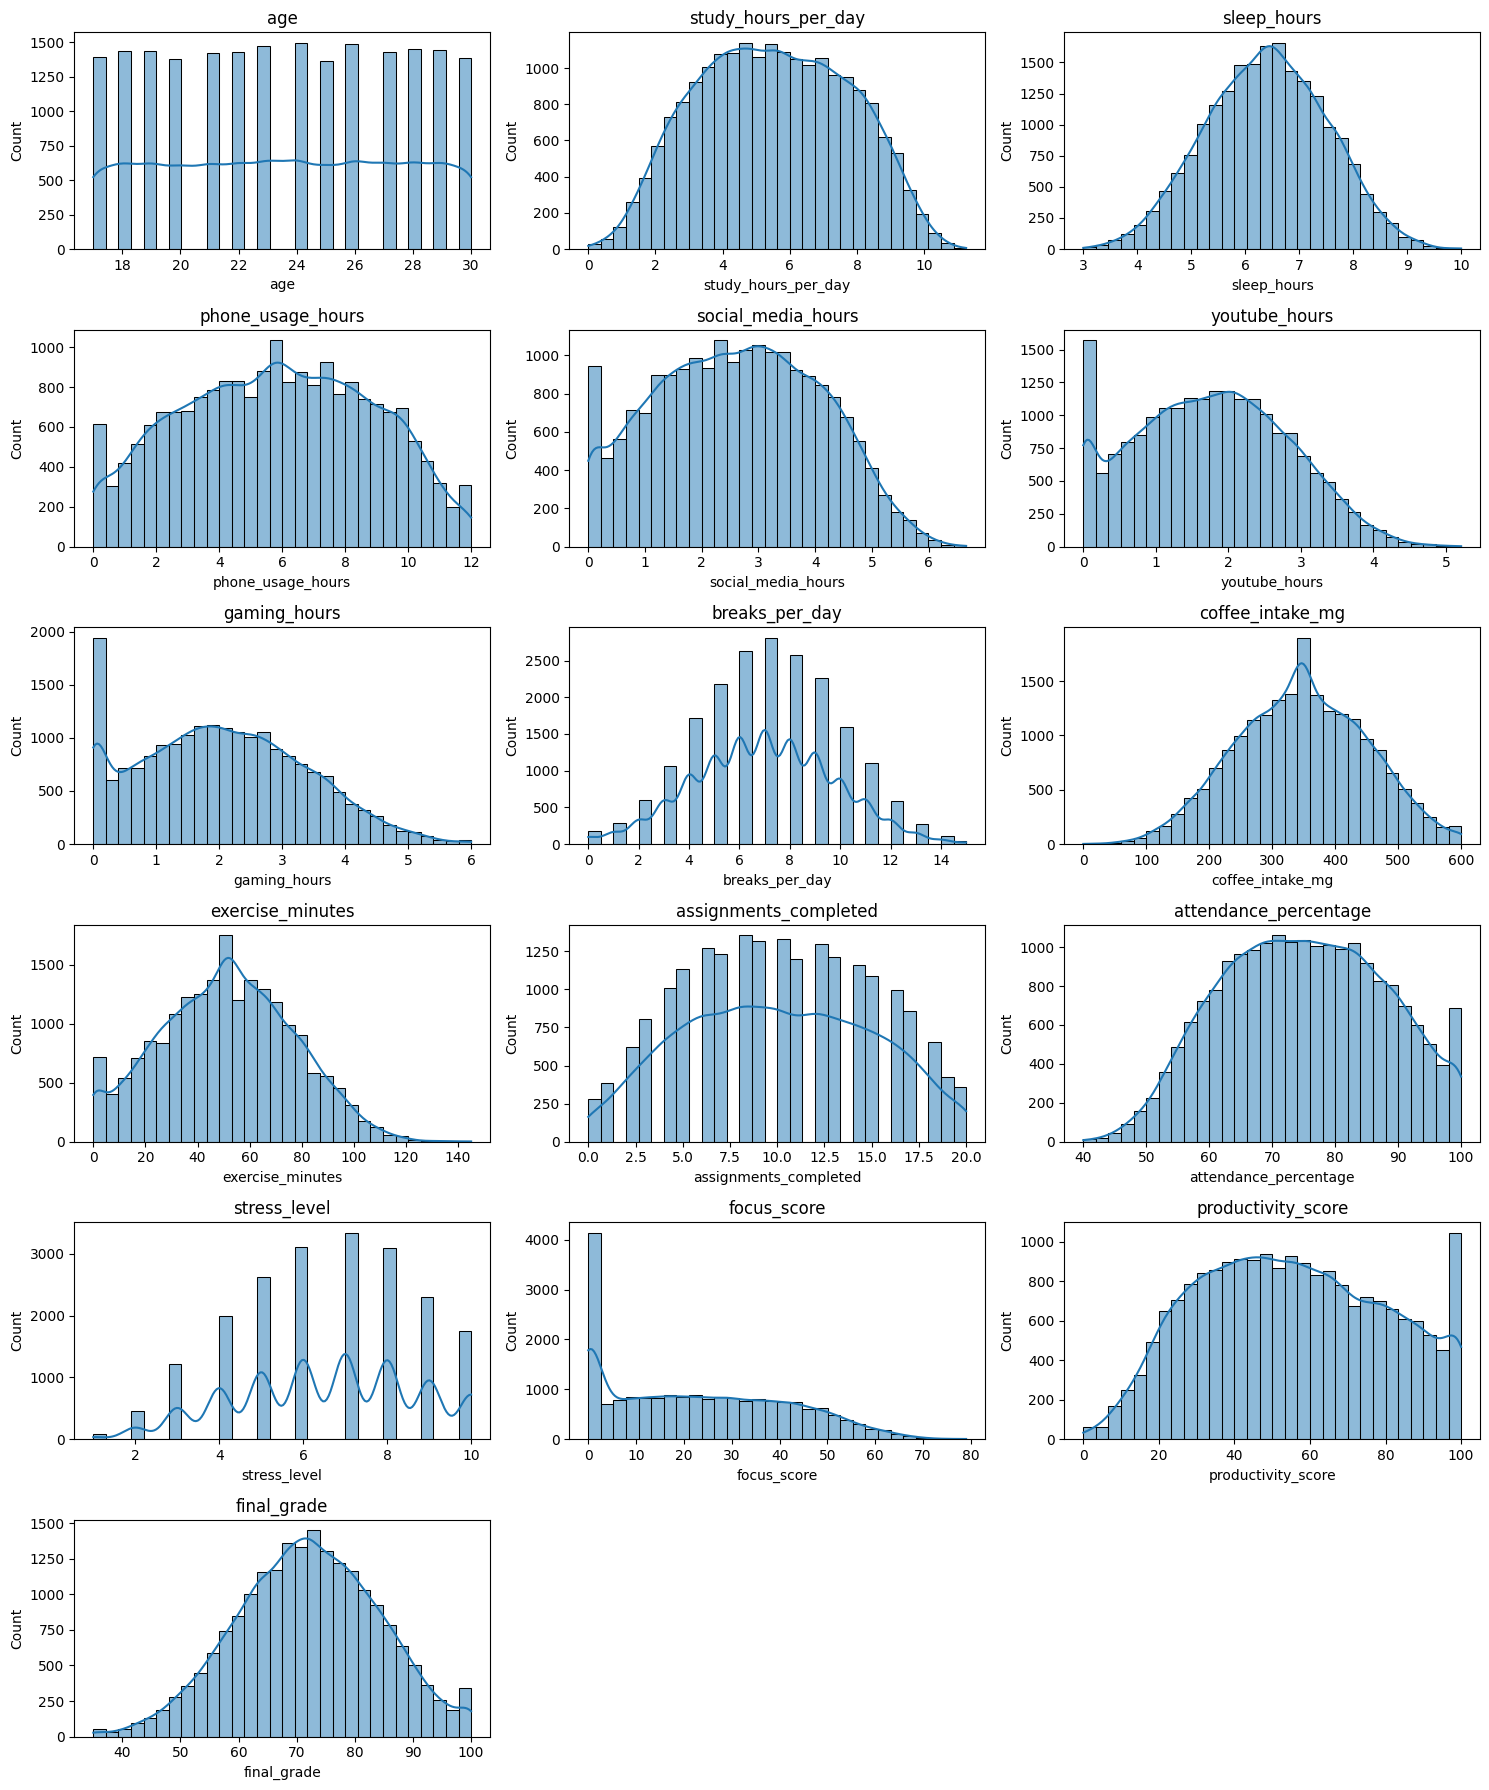

In [17]:
cols = df.select_dtypes(include="number").columns.tolist()
ncols = 3
nrows = (len(cols) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3 * nrows))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.histplot(df[col].dropna(), kde=True, bins=30, ax=axes[i])
    axes[i].set_title(col)

for j in range(len(cols), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

**What we see:** distributions look pretty normal. Most numeric columns spread out smoothly without huge spikes. Nothing looks broken.

Next we switch to boxplots for the same columns so we can spot outliers more easily.

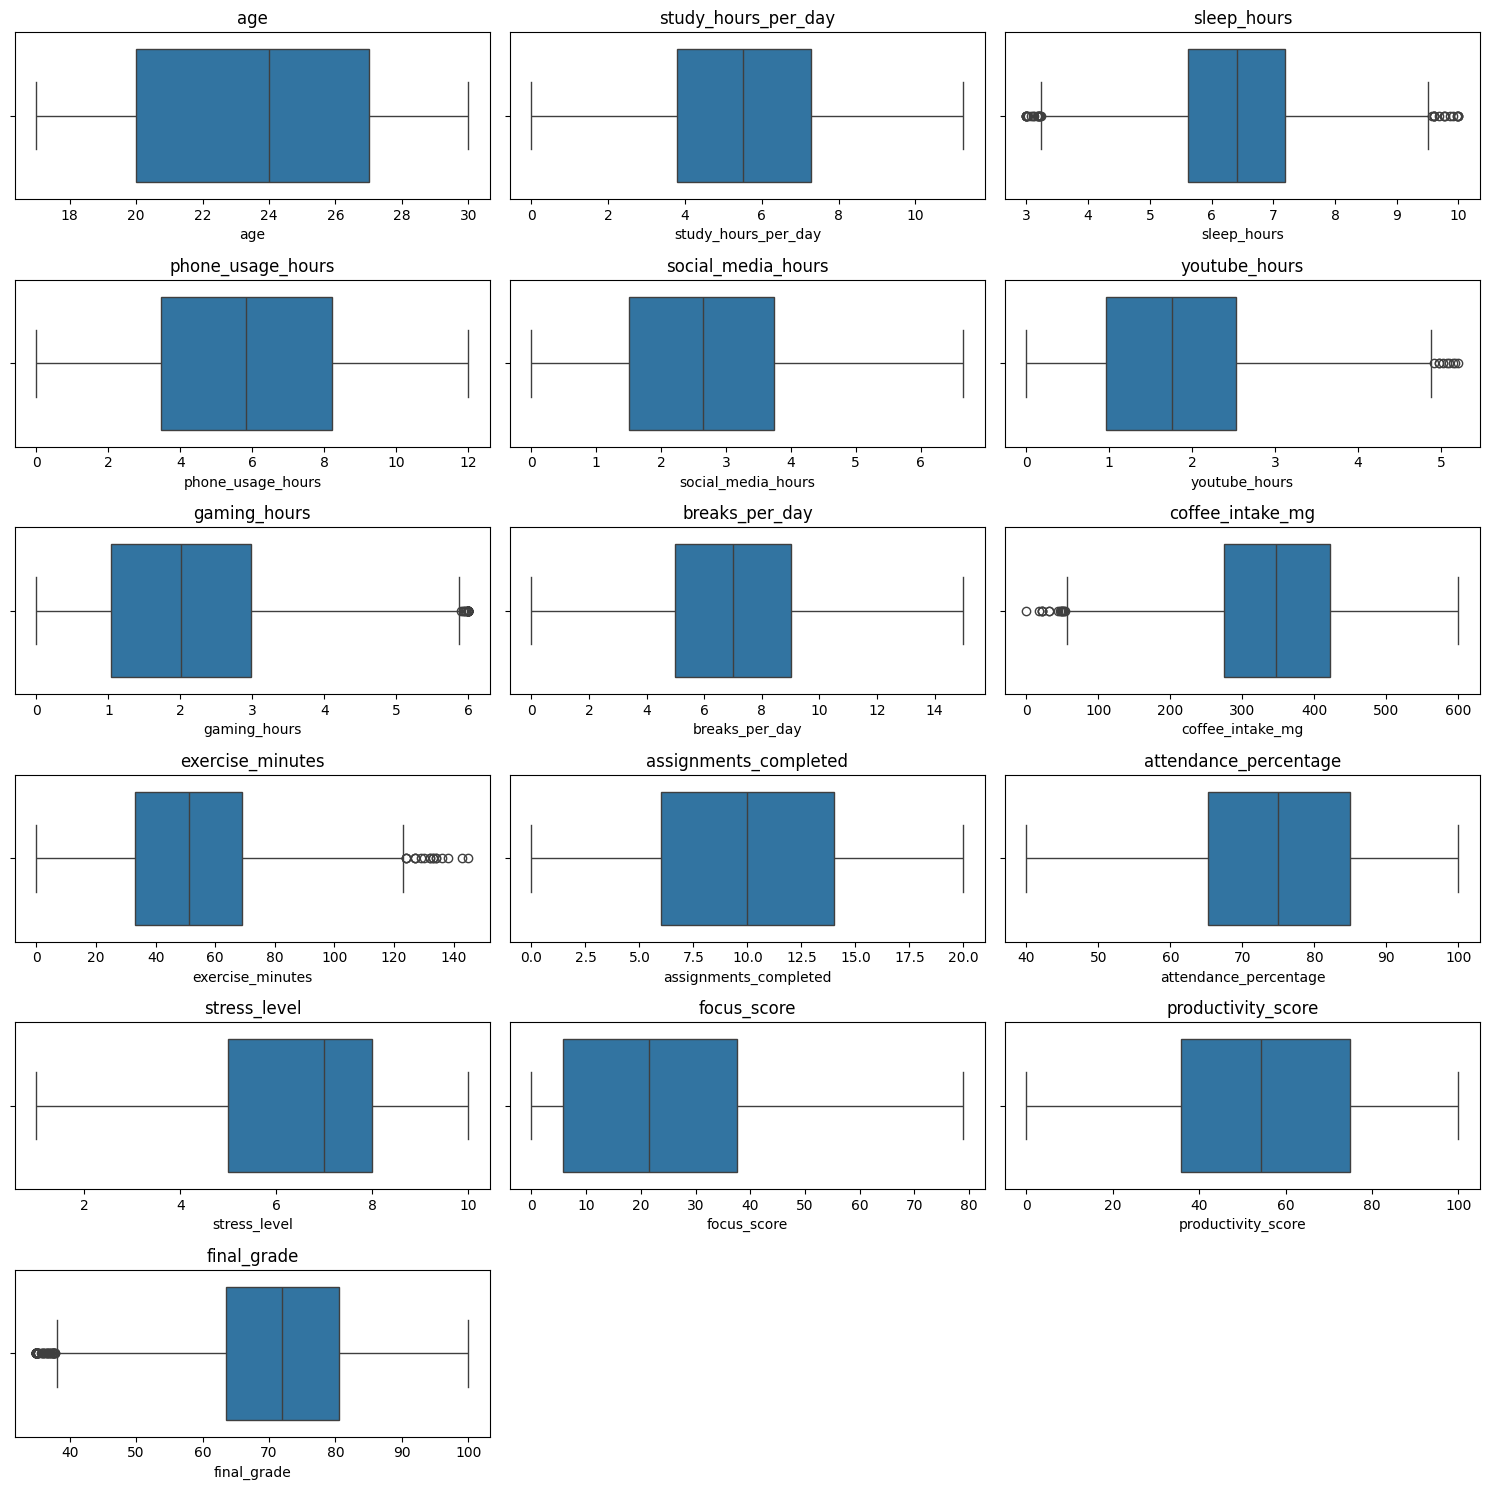

In [18]:
cols = df.select_dtypes(include="number").columns.tolist()
ncols, nrows = 3, (len(cols) + 2) // 3
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 2.5 * nrows))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(col)

for j in range(len(cols), len(axes)):
    axes[j].axis("off")
    
plt.tight_layout()
plt.show()

Here we look at boxplots to check for outliers in each numeric column.

**What we see:** most variables look fine. YouTube hours and phone usage have a few values on the high end. Nothing crazy, so we keep all the rows.

## Pairwise slices

Examples of joint behaviour (density, scatter, boxes, regression).


First pair: phone usage vs sleep hours. We plot the joint density and add a regression line on top to see if heavy phone users sleep less.

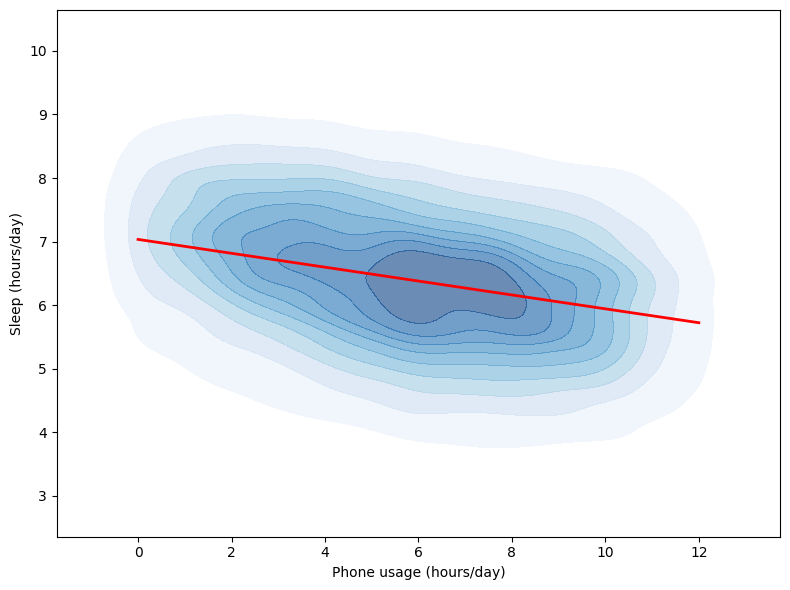

In [19]:
plt.figure(figsize=(8, 6))
sns.kdeplot(
    data=df, x="phone_usage_hours", y="sleep_hours",
    fill=True, thresh=0.05, alpha=0.6, cmap="Blues",
)
sns.regplot(
    data=df, x="phone_usage_hours", y="sleep_hours",
    scatter=False,
    line_kws={"color": "red", "linewidth": 2},
    ci=None,
)
plt.xlabel("Phone usage (hours/day)")
plt.ylabel("Sleep (hours/day)")
plt.tight_layout()
plt.show()

**What we see:** the red line slopes down a little. Heavy phone users sleep slightly less, but the cloud is wide so the effect is small.

Next we look at focus score vs coffee intake, colored by productivity. We want to know if more coffee really helps focus and output.

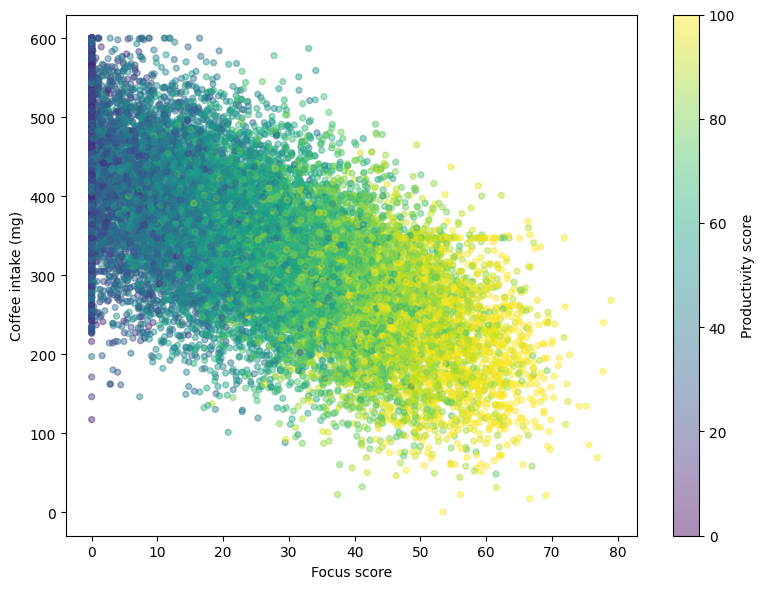

In [20]:
plt.figure(figsize=(8, 6))
sc = plt.scatter(
    df["focus_score"],
    df["coffee_intake_mg"],
    c=df["productivity_score"],
    cmap="viridis",
    alpha=0.45,
    s=18,
)
plt.colorbar(sc, label="Productivity score")
plt.xlabel("Focus score")
plt.ylabel("Coffee intake (mg)")
plt.tight_layout()
plt.show()

**What we see:** no clear pattern. Coffee amount does not really predict focus. The bright (high productivity) points are spread all over, not stacked at one corner.

Next, we check if stressed students drink more coffee. Boxplot of coffee intake by stress level.

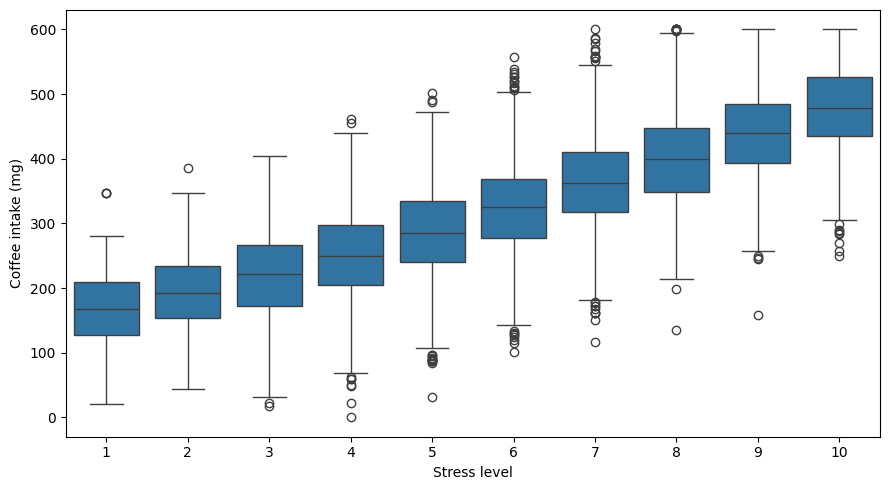

In [21]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x="stress_level", y="coffee_intake_mg")
plt.xlabel("Stress level")
plt.ylabel("Coffee intake (mg)")
plt.tight_layout()
plt.show()

**What we see:** the boxes are pretty similar across stress levels. People do not really drink more coffee when stressed, at least not in this dataset.

Finally, we plot stress vs focus with a regression line. We want to confirm if higher stress lowers focus.

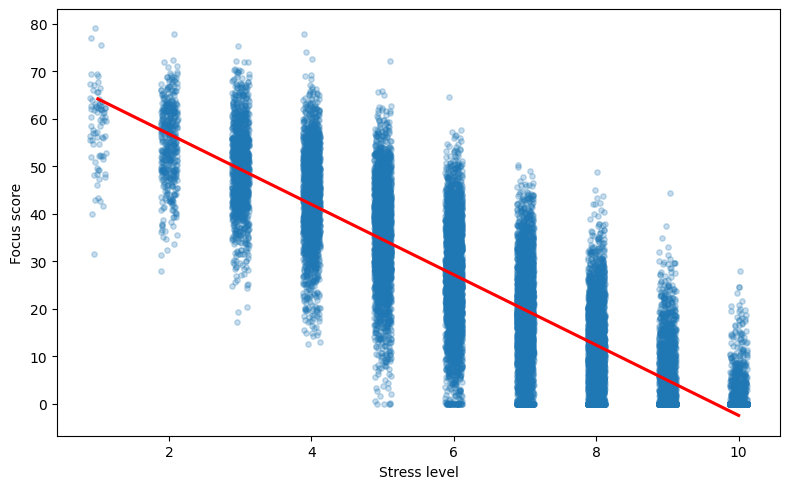

In [22]:
plt.figure(figsize=(8, 5))
sns.regplot(
    data=df,
    x="stress_level",
    y="focus_score",
    x_jitter=0.12,
    scatter_kws={"alpha": 0.25, "s": 15},
    line_kws={"color": "red"},
)
plt.xlabel("Stress level")
plt.ylabel("Focus score")
plt.tight_layout()
plt.show()

**What we see:** as stress goes up, focus clearly goes down. Strong negative trend.

## Screen time vs stress

Entertainment screen hours (social + YouTube + gaming) by self-reported stress level.


/var/folders/1z/695r5vjj25925ssfxxwjpmw80000gn/T/ipykernel_10302/1784276623.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


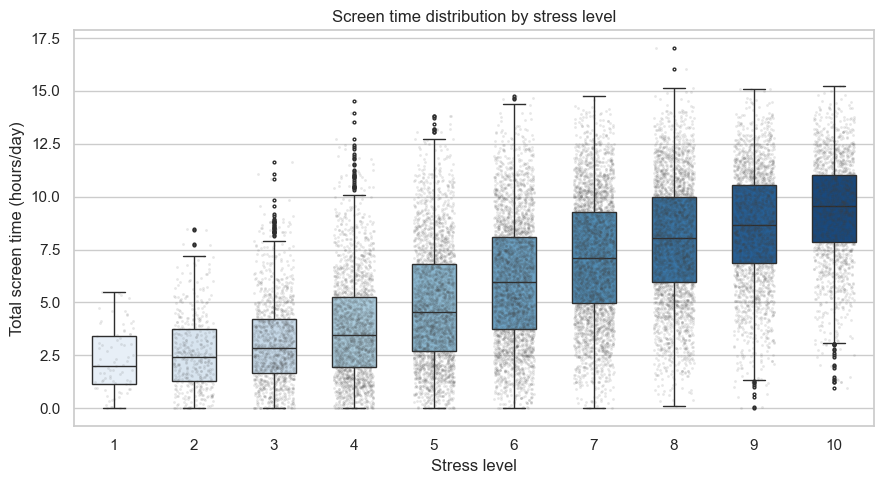

In [23]:
d = df.assign(
    total_screen_hours=df["social_media_hours"] + df["youtube_hours"] + df["gaming_hours"]
)

sns.set_theme(style="whitegrid", context="notebook")
plt.figure(figsize=(9, 5))
ax = sns.boxplot(
    data=d,
    x="stress_level",
    y="total_screen_hours",
    palette="Blues",
    width=0.55,
    fliersize=2,
)
sns.stripplot(
    data=d,
    x="stress_level",
    y="total_screen_hours",
    color="0.25",
    alpha=0.12,
    size=2,
    jitter=0.25,
    ax=ax,
)
plt.xlabel("Stress level")
plt.ylabel("Total screen time (hours/day)")
plt.title("Screen time distribution by stress level")
plt.tight_layout()
plt.show()

**What we see:** stressed students show a wider spread of screen time. The upper end gets bigger as stress goes up, but there is no clean cut where stressed students always watch more.

## Assignments vs grade (by exercise)

Exercise minutes split into tertiles; lines show mean final grade vs assignments completed.


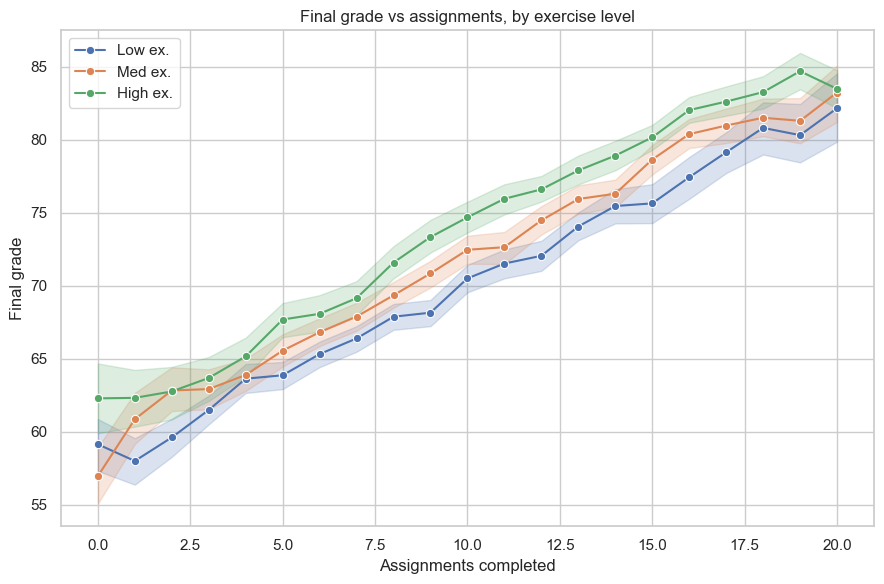

In [24]:
df = df.copy()
df["exercise_group"] = pd.qcut(
    df["exercise_minutes"], q=3, labels=["Low ex.", "Med ex.", "High ex."]
)
sns.set_theme(style="whitegrid", context="notebook")
plt.figure(figsize=(9, 6))
sns.lineplot(
    data=df,
    x="assignments_completed",
    y="final_grade",
    hue="exercise_group",
    err_style="band",
    marker="o",
    markersize=6,
)
plt.xlabel("Assignments completed")
plt.ylabel("Final grade")
plt.title("Final grade vs assignments, by exercise level")
plt.legend(title="")
plt.tight_layout()

**What we see:** more assignments completed means a higher final grade for every exercise group. The high exercise line sits a bit above the low one at each level. Exercise alone is a small boost but it adds up.

Next we put the top and low students on a radar so we can compare habits side by side.

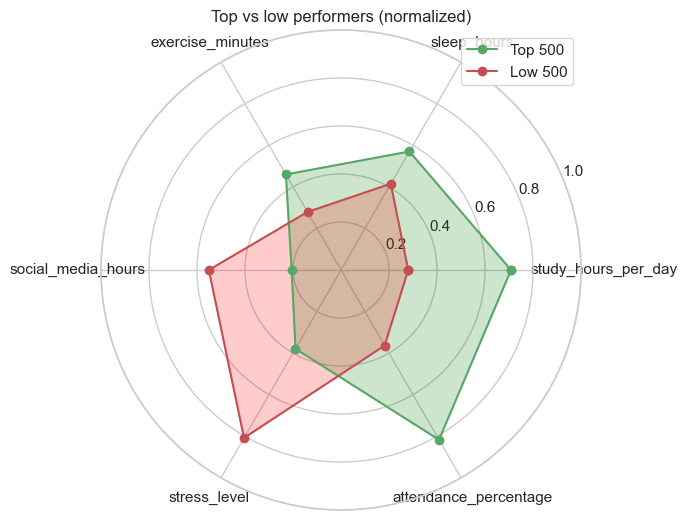

In [25]:
from sklearn.preprocessing import MinMaxScaler

vars_ = ["study_hours_per_day", "sleep_hours", "exercise_minutes",
         "social_media_hours", "stress_level", "attendance_percentage"]

# Scale all variables to 0-1 so they're comparable on the radar.
scaler = MinMaxScaler()
scaled = scaler.fit_transform(df[vars_])
df_scaled = pd.DataFrame(scaled, columns=vars_)

top_idx = df.nlargest(500, "final_grade").index
low_idx = df.nsmallest(500, "final_grade").index

top_means = df_scaled.loc[top_idx, vars_].mean().tolist()
low_means = df_scaled.loc[low_idx, vars_].mean().tolist()

angles = np.linspace(0, 2 * np.pi, len(vars_), endpoint=False).tolist()
top_means += top_means[:1]; low_means += low_means[:1]; angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
ax.plot(angles, top_means, "g-o", label="Top 500")
ax.fill(angles, top_means, alpha=0.2, color="green")
ax.plot(angles, low_means, "r-o", label="Low 500")
ax.fill(angles, low_means, alpha=0.2, color="red")
ax.set_thetagrids(np.degrees(angles[:-1]), vars_)
ax.set_ylim(0, 1)
ax.legend(loc="upper right")
plt.title("Top vs low performers (normalized)")
plt.tight_layout()
plt.show()

**What we see:** the two shapes are clearly different. Top 500 students study more, attend more classes and report lower stress. Low 500 use more social media and have higher stress.

## Grade × sleep bands

Cut final grade (Low/Mid/High) and sleep into tertiles; sunburst shows counts (colour encodes a tier index).


In [26]:
prep = df[["final_grade", "sleep_hours", "productivity_score"]].apply(
    pd.to_numeric, errors="coerce"
).dropna()

prep["grade_band"] = pd.cut(
    prep["final_grade"],
    [0, 60, 75, 100],
    labels=["Low", "Mid", "High"],
)
prep["sleep_band"] = pd.qcut(
    prep["sleep_hours"], 3, labels=["Short", "Med", "Long"], duplicates="drop"
)

agg = prep.groupby(["grade_band", "sleep_band"], observed=False).agg(
    students=("final_grade", "count"),
    avg_final=("final_grade", "mean"),
    avg_productivity=("productivity_score", "mean"),
).reset_index()

g = {"Low": 0, "Mid": 1, "High": 2}
s = {"Short": 0, "Med": 1, "Long": 2}
agg["tier"] = (
    agg["grade_band"].astype(str).map(g).astype(int) * 3
    + agg["sleep_band"].astype(str).map(s).astype(int)
)

fig = px.sunburst(
    agg,
    path=["grade_band", "sleep_band"],
    values="students",
    color="tier",
    color_continuous_scale="Cividis",
    range_color=[0, 8],
    hover_data={"avg_final": ":.1f", "avg_productivity": ":.1f"},
    title="Grade → sleep",
)
fig.update_traces(textinfo="label+percent entry")
fig.update_layout(margin=dict(t=45, l=8, r=8, b=8))
fig.show()

**What we see:** most High grade students fall in the Med or Long sleep bands. Low grade students show up more in the Short sleep group. Sleep is part of the picture but not the whole story.

## Correlation matrix

Pearson *r* among habits and outcomes (lower triangle).


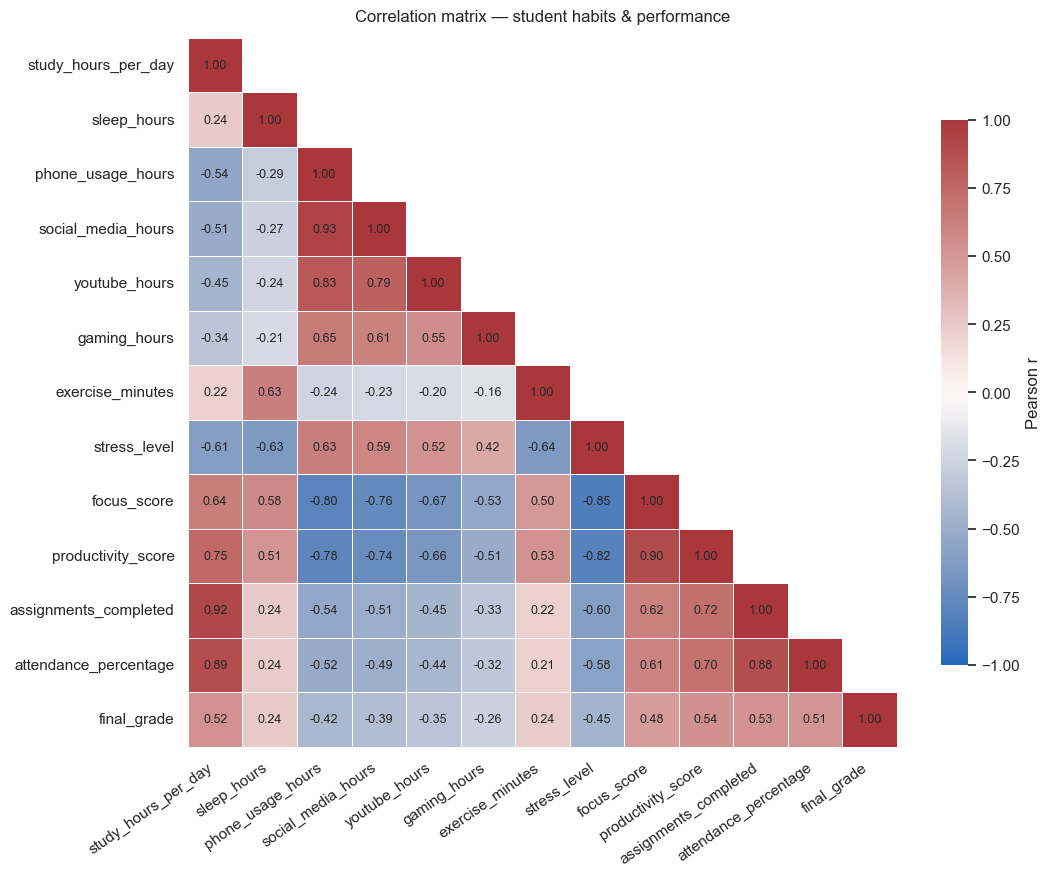

In [27]:
sns.set_theme(style="white", context="notebook")

# Core variables aligned with your proposal (digital, study, wellness, outcomes).
corr_cols = [
    "study_hours_per_day",
    "sleep_hours",
    "phone_usage_hours",
    "social_media_hours",
    "youtube_hours",
    "gaming_hours",
    "exercise_minutes",
    "stress_level",
    "focus_score",
    "productivity_score",
    "assignments_completed",
    "attendance_percentage",
    "final_grade",
]

c = df[corr_cols].corr(numeric_only=True)
mask = np.triu(np.ones_like(c, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    c,
    mask=mask,
    cmap="vlag",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.6,
    linecolor="white",
    annot=True,
    fmt=".2f",
    annot_kws={"size": 9, "color": "0.15"},
    cbar_kws={"shrink": 0.75, "label": "Pearson r"},
    ax=ax,
)
ax.set_title("Correlation matrix — student habits & performance", pad=12)
plt.xticks(rotation=35, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

**What we see:** assignments completed, attendance and study hours have the strongest positive link with final grade. Phone and social media hours pull the grade down. Stress and focus are strongly negative with each other. So daily habits really do show up in the numbers.